# Logistic Regression — Strategy A: SMOTE Oversampling

Logistic Regression is trained using SMOTE oversampling to address class imbalance between diabetic and non-diabetic participants. SMOTE generates synthetic samples for the minority class inside each training fold, preventing data leakage into the validation fold.

Hyperparameter tuning is performed using `GridSearchCV` with 10-fold stratified cross-validation. Because the Logistic Regression search space is small (6 × 2 = 12 combinations), `GridSearchCV` is used instead of `RandomizedSearchCV` to exhaustively evaluate all combinations.

The trained model is saved to disk after the first run so that subsequent runs load the fitted model directly, avoiding the cost of rerunning tuning and cross-validation.

Feature importance is assessed using three methods:
- **SHAP** (LinearExplainer): model-agnostic, interaction-aware
- **Permutation Importance**: model-agnostic, based on test set ROC AUC drop
- **Coefficients**: model-specific, absolute standardised logistic regression coefficients


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, classification_report,
    precision_score, recall_score, f1_score
)


## Loading the Preprocessed Dataset

The preprocessed training and test sets are loaded from Parquet files produced by `03_preprocessing.ipynb`. These datasets have already been imputed, encoded, and scaled. No further preprocessing is applied here.

In [2]:
X_train_final = pd.read_parquet("../../data/processed/X_train_final.parquet")
X_test_final  = pd.read_parquet("../../data/processed/X_test_final.parquet")
y_train = pd.read_parquet("../../data/processed/y_train.parquet")["diabetes"]
y_test  = pd.read_parquet("../../data/processed/y_test.parquet")["diabetes"]

print("Train shape:", X_train_final.shape)
print("Test shape: ", X_test_final.shape)


Train shape: (20800, 36)
Test shape:  (5201, 36)


## Hyperparameter Tuning with Cross-Validation

`GridSearchCV` with 10-fold stratified cross-validation is used to find the best hyperparameters. The search optimizes for ROC AUC, which is appropriate given the class imbalance in the dataset. SMOTE is included inside the pipeline so that synthetic samples are only generated on training folds.

The fitted model is saved to `models/logistic_regression_A.pkl` after the first run. On subsequent runs the saved model is loaded directly, skipping tuning entirely. To retune from scratch, delete the `.pkl` file and rerun this cell.

In [3]:
MODEL_PATH = "../../models/logistic_regression_A.pkl"
os.makedirs("../../models", exist_ok=True)

if os.path.exists(MODEL_PATH):
    best_model = joblib.load(MODEL_PATH)
    print("[OK] Model loaded from disk.")
else:
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    pipeline = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ])

    param_grid = {
        "model__C":       [0.001, 0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l1", "l2"],
        "model__solver":  ["liblinear"]
    }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_final, y_train)
    best_model = grid_search.best_estimator_

    print("Best parameters:", grid_search.best_params_)
    print("Best CV ROC AUC:", grid_search.best_score_)

    joblib.dump(best_model, MODEL_PATH)
    print("[OK] Model saved to", MODEL_PATH)


Fitting 10 folds for each of 12 candidates, totalling 120 fits
Best parameters: {'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV ROC AUC: 0.8091707180428382
[OK] Model saved to ../../models/logistic_regression_A.pkl


## Final Test Set Evaluation

The best model is evaluated on the held-out test set. The test set is never resampled and preserves the original class distribution, so that evaluation reflects real-world performance.

Performance is measured using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

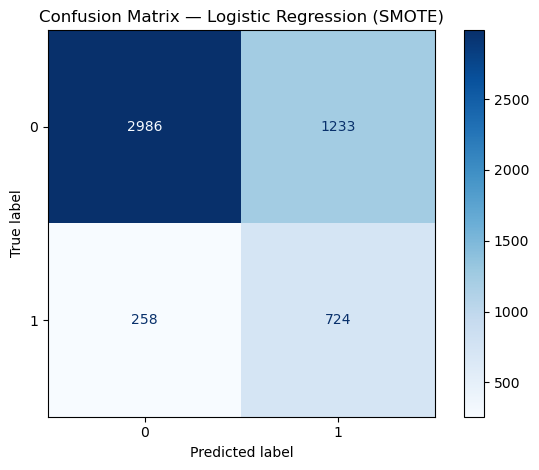

Accuracy: 0.7133
ROC AUC:  0.8023

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.71      0.80      4219
         1.0       0.37      0.74      0.49       982

    accuracy                           0.71      5201
   macro avg       0.65      0.72      0.65      5201
weighted avg       0.82      0.71      0.74      5201



In [4]:
predictions        = best_model.predict(X_test_final)
pred_probabilities = best_model.predict_proba(X_test_final)[:, 1]

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Logistic Regression (SMOTE)")
plt.tight_layout()
plt.show()

accuracy = accuracy_score(y_test, predictions)
roc_auc  = roc_auc_score(y_test, pred_probabilities)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC:  {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))


## Exporting Model Performance Metrics

Evaluation metrics are exported to a CSV file in `results/performance/`. This allows the comparison notebook to load results from all models without retraining.

In [5]:
os.makedirs("../../results/performance", exist_ok=True)

metrics = {
    "Model":     "Logistic Regression",
    "Strategy":  "SMOTE",
    "Accuracy":  accuracy_score(y_test, predictions),
    "Precision": precision_score(y_test, predictions),
    "Recall":    recall_score(y_test, predictions),
    "F1-score":  f1_score(y_test, predictions),
    "ROC AUC":   roc_auc_score(y_test, pred_probabilities),
}

pd.DataFrame([metrics]).to_csv(
    "../../results/performance/logistic_regression_A_metrics.csv",
    index=False
)
print("[OK] Performance metrics saved.")


[OK] Performance metrics saved.


## Feature Importance — SHAP (LinearExplainer)

`shap.LinearExplainer` computes exact Shapley values for linear models by exploiting the linearity of the model. It uses the training data to estimate feature correlations, which are needed to correctly attribute importance in the presence of correlated predictors.

The explainer is fitted on `X_train_final` and applied to `X_test_final`. The mean absolute SHAP value across all test observations is used as the overall importance score. The full ranking across all features is exported for comparison in the comparison notebook.

/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
Background dataset has 20800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=20800 when initializing the masker.


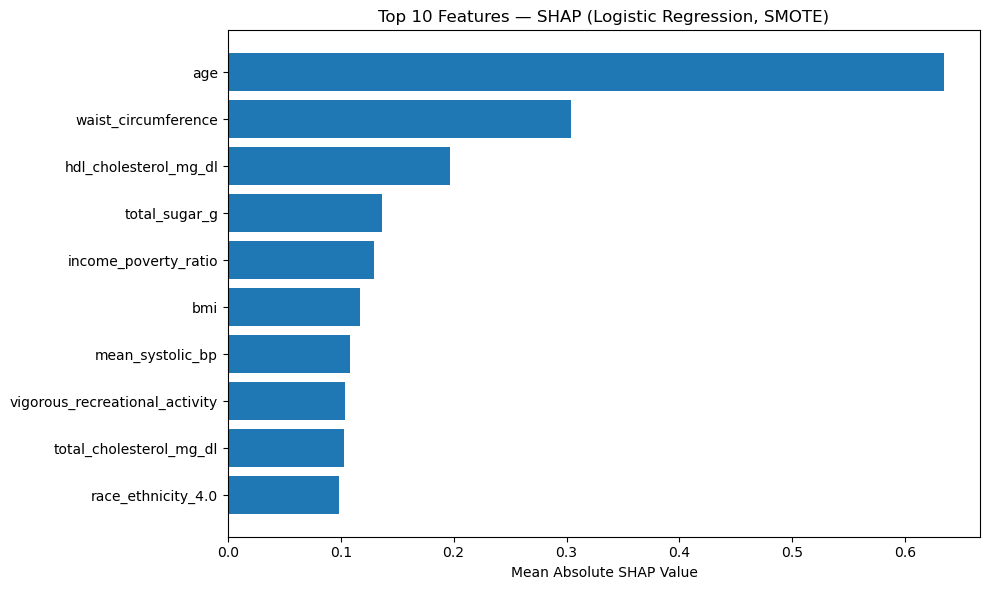

In [6]:
lr_model = best_model.named_steps["model"]

explainer  = shap.LinearExplainer(lr_model, X_train_final, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_final)

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature":    X_test_final.columns,
    "Importance": mean_abs_shap
}).sort_values("Importance", ascending=False).reset_index(drop=True)

shap_df["Rank"]     = range(1, len(shap_df) + 1)
shap_df["Model"]    = "Logistic Regression"
shap_df["Strategy"] = "SMOTE"
shap_df["Method"]   = "SHAP"

# Plot top 10
top10 = shap_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Top 10 Features — SHAP (Logistic Regression, SMOTE)")
plt.tight_layout()
plt.show()


## Feature Importance — Permutation Importance

Permutation importance measures how much the model's ROC AUC drops when the values of a single feature are randomly shuffled. A large drop indicates that the model relies heavily on that feature; a small or negative drop suggests the feature contributes little.

Permutation importance is computed on the full pipeline using the held-out test set. `n_repeats=20` shuffles each feature 20 times to reduce variance in the estimate. The full ranking across all features is exported for comparison.

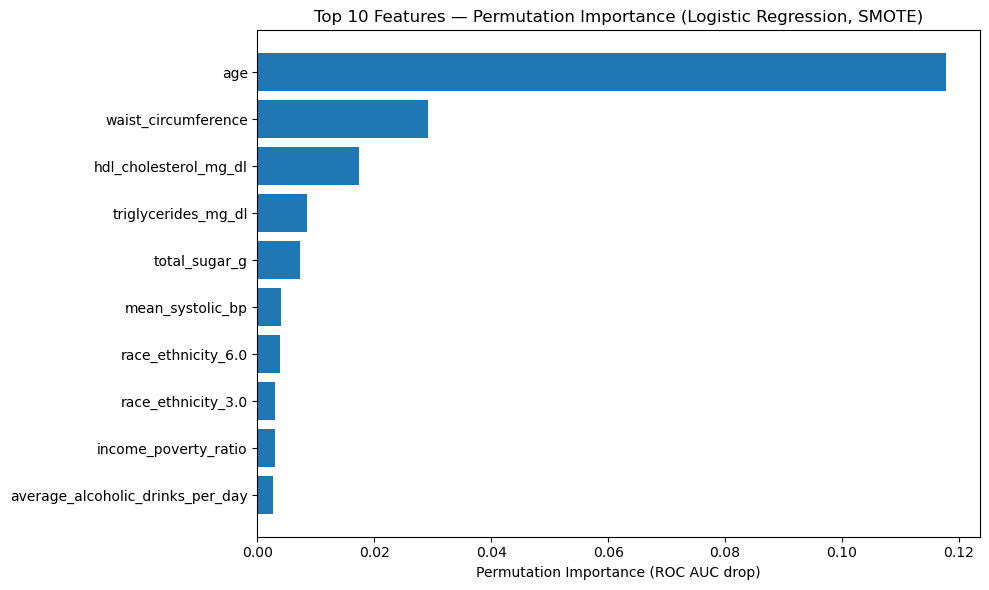

In [7]:
perm_result = permutation_importance(
    best_model,
    X_test_final,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature":        X_test_final.columns,
    "Importance":     perm_result.importances_mean,
    "Importance Std": perm_result.importances_std
}).sort_values("Importance", ascending=False).reset_index(drop=True)

perm_df["Rank"]     = range(1, len(perm_df) + 1)
perm_df["Model"]    = "Logistic Regression"
perm_df["Strategy"] = "SMOTE"
perm_df["Method"]   = "Permutation"

# Plot top 10
top10 = perm_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])
plt.xlabel("Permutation Importance (ROC AUC drop)")
plt.title("Top 10 Features — Permutation Importance (Logistic Regression, SMOTE)")
plt.tight_layout()
plt.show()


## Feature Importance — Model-Specific Coefficients

For Logistic Regression the model-specific importance measure is the absolute value of the fitted coefficients. Because the features have already been standardised during preprocessing, the coefficients are directly comparable across features: a larger absolute coefficient means a one-standard-deviation change in that feature has a stronger effect on the log-odds of diabetes.

The full ranking across all features is exported for comparison.

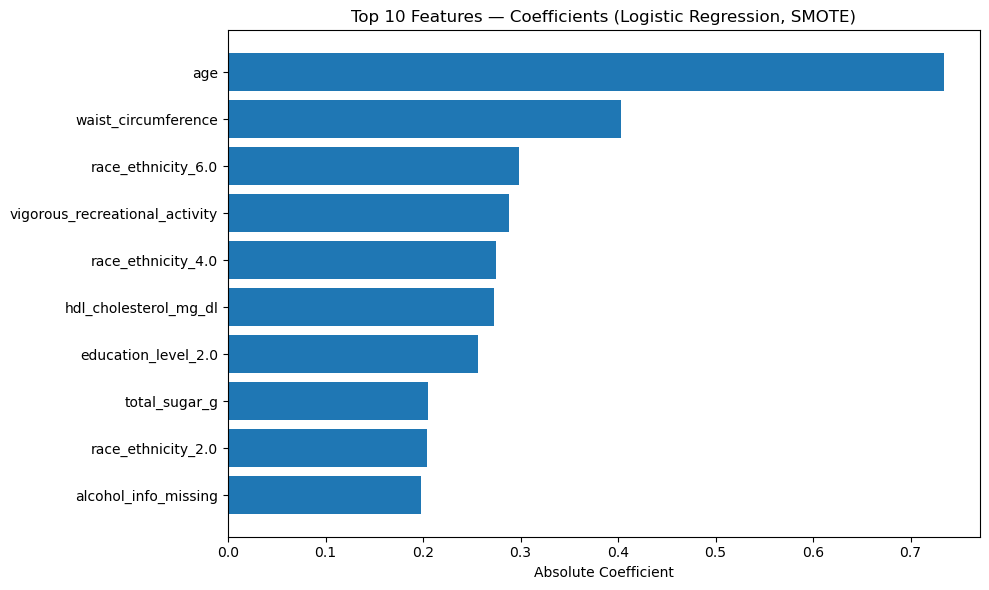

In [8]:
lr_model = best_model.named_steps["model"]

coef_importance = np.abs(lr_model.coef_[0])

coef_df = pd.DataFrame({
    "Feature":    X_test_final.columns,
    "Importance": coef_importance
}).sort_values("Importance", ascending=False).reset_index(drop=True)

coef_df["Rank"]     = range(1, len(coef_df) + 1)
coef_df["Model"]    = "Logistic Regression"
coef_df["Strategy"] = "SMOTE"
coef_df["Method"]   = "Coefficient"

# Plot top 10
top10 = coef_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])
plt.xlabel("Absolute Coefficient")
plt.title("Top 10 Features — Coefficients (Logistic Regression, SMOTE)")
plt.tight_layout()
plt.show()


## Exporting Feature Importance Rankings

All three importance rankings are combined into a single CSV file in `results/features/`. Each row represents one feature under one method, with its importance score and rank. The full ranking (not just top 10) is saved so that Spearman rank correlations can be computed across all features in the comparison notebook.

In [9]:
os.makedirs("../../results/features", exist_ok=True)

cols = ["Model", "Strategy", "Method", "Rank", "Feature", "Importance"]

feature_importance_all = pd.concat([
    shap_df[cols],
    perm_df[cols],
    coef_df[cols]
], ignore_index=True)

feature_importance_all.to_csv(
    "../../results/features/logistic_regression_A_feature_importance.csv",
    index=False
)
print("[OK] Feature importance rankings saved.")
display(feature_importance_all.head(15))


[OK] Feature importance rankings saved.


,Model,Strategy,Method,Rank,Feature,Importance
0,Logistic Regression,SMOTE,SHAP,1,age,0.634669
1,Logistic Regression,SMOTE,SHAP,2,waist_circumference,0.303871
2,Logistic Regression,SMOTE,SHAP,3,hdl_cholesterol_mg_dl,0.197142
3,Logistic Regression,SMOTE,SHAP,4,total_sugar_g,0.136475
4,Logistic Regression,SMOTE,SHAP,5,income_poverty_ratio,0.129355
5,Logistic Regression,SMOTE,SHAP,6,bmi,0.116798
6,Logistic Regression,SMOTE,SHAP,7,mean_systolic_bp,0.107853
7,Logistic Regression,SMOTE,SHAP,8,vigorous_recreational_activity,0.103326
8,Logistic Regression,SMOTE,SHAP,9,total_cholesterol_mg_dl,0.102603
9,Logistic Regression,SMOTE,SHAP,10,race_ethnicity_4.0,0.0987
